<a href="https://colab.research.google.com/github/Modhu54/Chemical-Engineering-Problems/blob/main/CSTR_Dynamic_response.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math
from math import *

Major governing equation of dynamic CSTR reactor

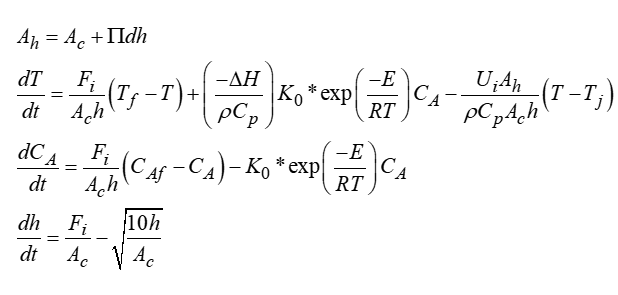

Initialization of Model Parameters :

In [ ]:
d=2.335              #Diameter of the reactor
AC=4.2822            # Cross sectional area
Caf=10.0             # Concentration of reactant A in the feed stream
Me=0.14              # Ui/(RowCp)
Y=5960.24157         # Y = E/R
dt=0.005             # time width
Z=34930800           # Frequency factor
X=416375136          # X = (-HZ)/(Row*Cp)


In [ ]:
d=2.335
AC=4.2822                  # Cross sectional area




In [ ]:
T0 = 120                  # initial reactor temperature
Ca0 = 1                   # initial reactor temperature
h0 = 2.335201              # initial liquid height in the reactor


t =0
Tj0 = 25                   # Initial Jacket temperature
Fi = 10                    # Feed flow rate
Tf = 25                    # Feed temperature

T_pts= []
Ca_pts = []
h_pts = []
t_pts = []

#AH=AC+3.14159*d*h0         # Heat transfer area

#AH - > Heat transfer area, m2
#T - > Reactor temperature, K
#Ca - >concentration of reactant A in the exit stream, kmol/m3
#h - > height of the reactor liquid, m
while t<25:
  AH=AC+3.14159*d*h0

  T=T0+dt*((X*Ca0*exp(-Y/(273.0+T0)))-(((Me*AH)/(AC*h0))*(T0-Tj0))+((Tf-T0)*(Fi/(AC*h0))))

  Ca=Ca0+dt*(((Fi/(AC*h0))*(Caf-Ca0))-(Z*Ca0*exp(-Y/(273.0+T0))))

  h=h0+dt*((Fi/AC)-(pow((10.0*h0/AC),0.5)))


  T_pts.append(T)
  Ca_pts.append(Ca)
  h_pts.append(h)
  t_pts.append(t)

  t +=dt
  T0 = T
  Ca0 = Ca
  h0 = h



In [ ]:
import matplotlib.pyplot as plt
import numpy as np

Reactor temperature dynamics

([<matplotlib.axis.XTick at 0x7eda303c6ed0>,
 [Text(0, 0, '0'),
  Text(5, 0, '5'),
  Text(10, 0, '10'),
  Text(15, 0, '15'),
  Text(20, 0, '20'),
  Text(25, 0, '25')])

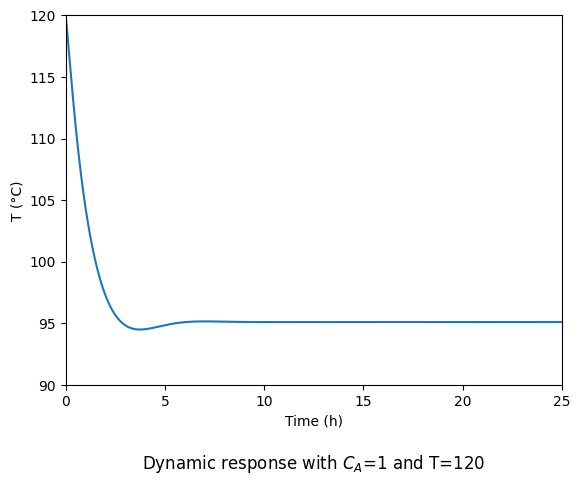

In [ ]:
plt.plot(t_pts,T_pts, label ='Reactor temperature')
plt.axvline(x=0, c="black",linewidth=0.5)
plt.axhline(y=0, c="black",linewidth=0.5)
plt.title("Dynamic response with $C_{A}$=1 and T=120", y=-0.25)
plt.xlabel('Time (h)')
plt.ylabel('T (°C)')
plt.ylim([90, 120])
plt.xlim([0,25])
plt.yticks(np.arange(90, 121, 5))
plt.xticks(np.arange(0, 26, 5))

Concentration dynamics

([<matplotlib.axis.XTick at 0x7eda2b62ac00>,
 [Text(0, 0, '0'),
  Text(5, 0, '5'),
  Text(10, 0, '10'),
  Text(15, 0, '15'),
  Text(20, 0, '20'),
  Text(25, 0, '25')])

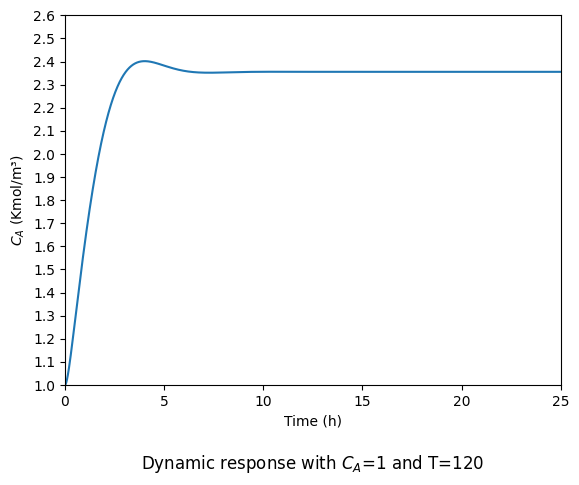

In [ ]:
plt.plot(t_pts, Ca_pts, label = 'Concentration')
plt.axvline(x=0, c="black",linewidth=0.5)
plt.axhline(y=0, c="black",linewidth=0.5)
plt.title("Dynamic response with $C_{A}$=1 and T=120", y=-0.25)
plt.xlabel('Time (h)')
plt.ylabel(r'$C_{A}$' ' (Kmol/m\u00b3)')
plt.ylim([1,2.6])
plt.xlim([0,25])
plt.yticks(np.arange(1, 2.7, 0.1))
plt.xticks(np.arange(0, 26, 5))